In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

c:\Users\pumas\AppData\Local\Programs\Python\Python313\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class State(TypedDict):
    runs:int
    balls:int
    strike_rate:float
    fours:int
    sixes:int
    balls_per_boundary:float
    boundry_percentage:float
    summary:str

In [3]:
def calculate_SR(old_state:State) -> State:
    balls = old_state["balls"]
    runs = old_state["runs"]
    sr = round((runs/balls) * 100,2)

    return {"strike_rate":sr}


def calculate_BPB(old_state:State) -> State:
    balls = old_state["balls"]
    fours = old_state["fours"]
    sixes = old_state["sixes"]
    bpb = round(balls/(fours+sixes),2)

    return {"balls_per_boundary":bpb}

def calculate_BPercent(old_state:State) -> State:
    runs = old_state["runs"]
    fours = old_state["fours"]
    sixes = old_state["sixes"]
    bp = round(((fours * 4) + (sixes * 6)) / runs * 100,2)

    return {"boundry_percentage":bp}


def summary(old_state: State) -> State:
    match_summary = f"""Summary of the Match:

Runs: {old_state["runs"]}
Fours: {old_state["fours"]}
Sixes: {old_state["sixes"]}
Strike Rate: {old_state["strike_rate"]}
Balls per Boundary: {old_state["balls_per_boundary"]}
Boundary Percentage: {old_state["boundry_percentage"]}"""

    return {"summary": match_summary}

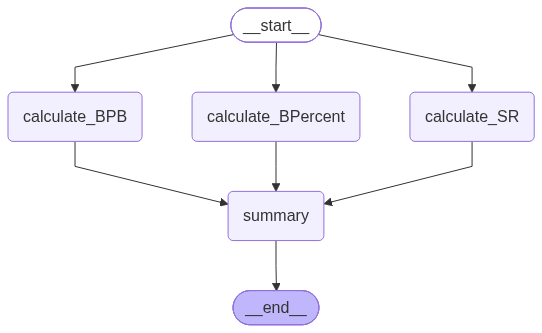

In [4]:
graph = StateGraph(State)

graph.add_node("calculate_SR",calculate_SR)
graph.add_node("calculate_BPB",calculate_BPB)
graph.add_node("calculate_BPercent",calculate_BPercent)
graph.add_node("summary",summary)


graph.add_edge(START,"calculate_SR")
graph.add_edge(START,"calculate_BPB")
graph.add_edge(START,"calculate_BPercent")

graph.add_edge("calculate_SR","summary")
graph.add_edge("calculate_BPB","summary")
graph.add_edge("calculate_BPercent","summary")

graph.add_edge("summary",END)


workflow = graph.compile()
workflow

In [5]:
initial_state = {
    "balls": 50,
    "runs": 80,
    "fours": 8,
    "sixes": 3
}

response = workflow.invoke(initial_state)
print(response)

{'runs': 80, 'balls': 50, 'strike_rate': 160.0, 'fours': 8, 'sixes': 3, 'balls_per_boundary': 4.55, 'boundry_percentage': 62.5, 'summary': 'Summary of the Match:\n\nRuns: 80\nFours: 8\nSixes: 3\nStrike Rate: 160.0\nBalls per Boundary: 4.55\nBoundary Percentage: 62.5'}


In [7]:
response

{'runs': 80,
 'balls': 50,
 'strike_rate': 160.0,
 'fours': 8,
 'sixes': 3,
 'balls_per_boundary': 4.55,
 'boundry_percentage': 62.5,
 'summary': 'Summary of the Match:\n\nRuns: 80\nFours: 8\nSixes: 3\nStrike Rate: 160.0\nBalls per Boundary: 4.55\nBoundary Percentage: 62.5'}